In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


In [7]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))   # [-1,1]
])

dataset = datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

loader = DataLoader(dataset,batch_size=64,shuffle=True)


In [8]:
class EncoderDecoder(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3,64,4,2,1),
            nn.ReLU(),

            nn.Conv2d(64,128,4,2,1),
            nn.ReLU(),

            nn.Conv2d(128,256,4,2,1),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256,128,4,2,1),
            nn.ReLU(),

            nn.ConvTranspose2d(128,64,4,2,1),
            nn.ReLU(),

            nn.ConvTranspose2d(64,3,4,2,1),
            nn.Tanh()
        )

    def forward(self,x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


model = EncoderDecoder()

In [9]:
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(),lr=0.0002)

In [10]:
epochs = 5

for epoch in range(epochs):

    total_loss = 0

    for imgs,_ in loader:

        imgs = imgs

        output = model(imgs)

        loss = criterion(output,imgs)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1} Loss {total_loss/len(loader):.4f}")

Epoch 1 Loss 0.1378
Epoch 2 Loss 0.0826
Epoch 3 Loss 0.0696
Epoch 4 Loss 0.0616
Epoch 5 Loss 0.0564


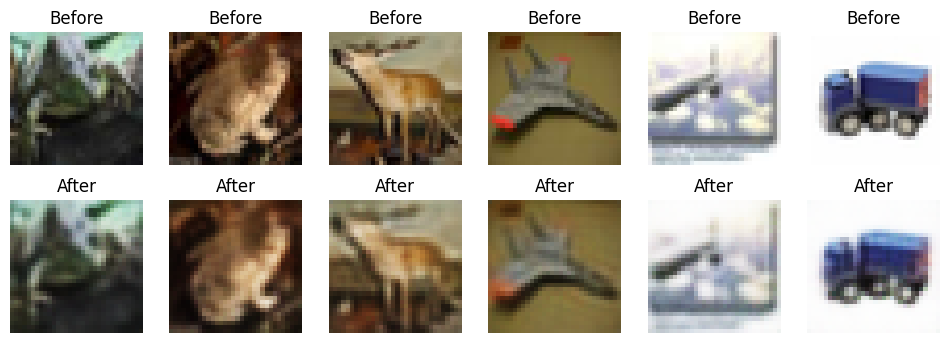

In [11]:
def denorm(x):
    return (x+1)/2

dataiter = iter(loader)
images,_ = next(dataiter)

images = images

with torch.no_grad():
    reconstructed = model(images)

images = images.cpu()
reconstructed = reconstructed.cpu()

fig,axs = plt.subplots(2,6,figsize=(12,4))

for i in range(6):

    # BEFORE
    axs[0,i].imshow(denorm(images[i]).permute(1,2,0))
    axs[0,i].set_title("Before")
    axs[0,i].axis("off")

    # AFTER
    axs[1,i].imshow(denorm(reconstructed[i]).permute(1,2,0))
    axs[1,i].set_title("After")
    axs[1,i].axis("off")

plt.show()